# Linear Regression

#### This notebook applies Linear Regression as a baseline model for predicting whether a basketball player is a good free throw shooter.

#### Since Linear Regression outputs continuous values, predictions are converted into binary classes using a threshold.

#### Linear Regression was used as a baseline model for comparison.

#### Although it is not designed for classification tasks, it provides insight into feature relationships. Predictions were converted into binary classes using a threshold of 0.5.

#### The model generally performs worse than classification models, which is expected.

#### Linear Regression is not inherently suitable for classification, 
#### but it was used as a baseline to compare performance with classification models.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_data.csv")

df.head()

,Age,MP,G,GS,FG%,3P%,2P%,eFG%,FTA,PTS,AST,TRB,TOV,GoodFT,Pos_F,Pos_PF,Pos_PG,Pos_SF,Pos_SG
0,23.0,43.2,82.0,7.0,0.512,0.311,0.475,0.484,9.7,34.5,2.2,14.1,1.0,0,False,False,False,False,False
1,30.0,40.4,80.0,7.0,0.464,0.311,0.475,0.484,5.5,30.6,6.2,5.7,1.0,1,False,False,False,True,False
2,27.0,42.3,65.0,7.0,0.513,0.311,0.475,0.484,6.6,30.0,4.1,14.0,1.0,0,False,False,False,False,False
3,26.0,39.6,82.0,7.0,0.456,0.311,0.475,0.484,9.1,26.5,6.8,2.7,1.0,1,False,False,True,False,False
4,26.0,37.6,69.0,7.0,0.441,0.311,0.475,0.484,5.1,24.3,4.5,4.0,1.0,0,False,False,True,False,False


In [3]:
X = df.drop("GoodFT", axis=1)
y = df["GoodFT"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
y_pred_continuous = model.predict(X_test)

In [7]:
y_pred = (y_pred_continuous > 0.5).astype(int)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8556759840273817


In [9]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92      4496
           1       0.67      0.01      0.02       763

    accuracy                           0.86      5259
   macro avg       0.76      0.50      0.47      5259
weighted avg       0.83      0.86      0.79      5259



In [10]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[4492    4]
 [ 755    8]]


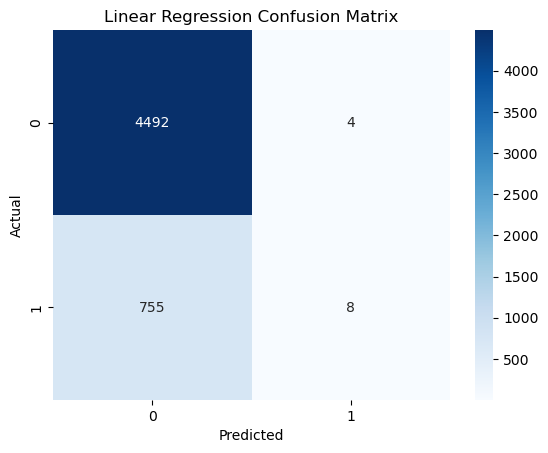

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear Regression Confusion Matrix")
plt.show()

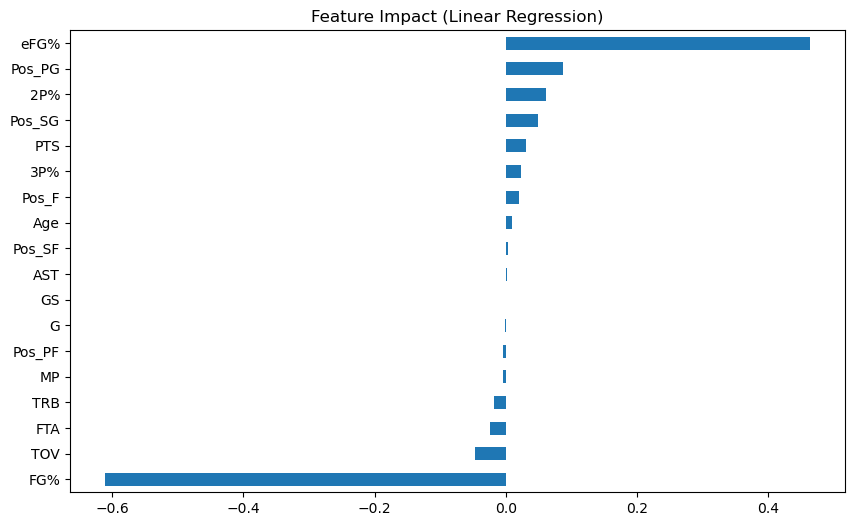

In [12]:
coefficients = pd.Series(model.coef_, index=X.columns)

coefficients.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Impact (Linear Regression)")
plt.show()